In [1]:
cd tumbling_git

/share/nas2/pryder/tumbling_git


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from period_utils import *


In [ ]:
freq = 1295e6
c= 299792458

## Autocorrelation

In [4]:
# spectrogram = np.load('/share/nas2/pryder/tumbling_git/exploring_parameters_results/spectrogram_intelsat_128_64.npy')
spec_0 = np.load('./spectrogram___intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_1 = np.load('./spectrogram_a_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_2 = np.load('./spectrogram_b_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_3 = np.load('./spectrogram_c_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')

In [9]:
zeros = np.zeros((256, 10))
combined_spec = np.hstack((spec_0, spec_1, spec_2, spec_3))
combined_spec.shape
spectrogram = combined_spec

In [10]:
max_velocity = c / (4 * 19.7e-3* (freq))
time = np.arange(spectrogram.shape[1])*19.7e-3*128

#### Checking what the spectrogram looks like

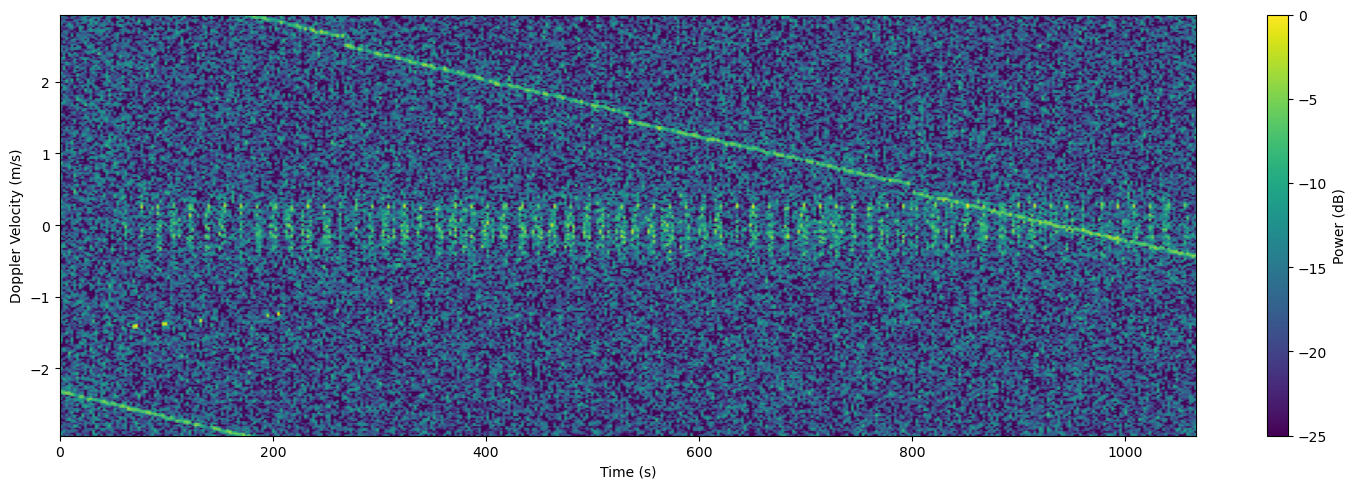

In [11]:
plt.figure(figsize=(15, 5))
plt.imshow(10 * np.log10(combined_spec+1e-12)-np.max(10 * np.log10(combined_spec+1e-12)), aspect='auto', origin='lower', vmin=-25, vmax=0, extent= [0, time[-1], -max_velocity, max_velocity])
# plt.title("Micro-Doppler Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Velocity (m/s)")
plt.colorbar(label='Power (dB)')
plt.tight_layout()

#### Now performing autocorrelation row wise on spectrogram. 

In [14]:
autocorrelation = np.zeros_like(spectrogram)
for n in range(spectrogram.shape[1]):
    row = spectrogram[:, n]
    print(len(row))
    print(len(autocorrelation[:, n]))
    autocorrelation[:, n] = np.correlate(row, row)

autocorrelation = np.sum(autocorrelation, axis=1)

256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256


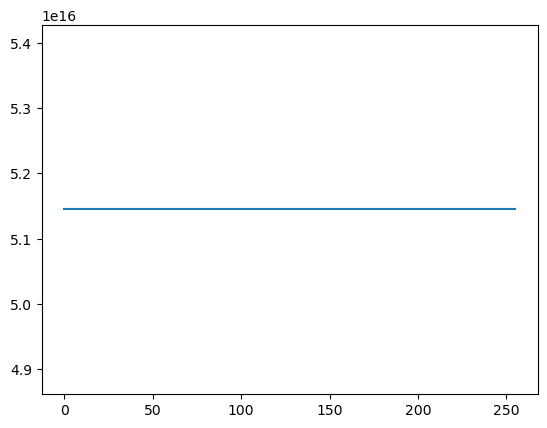

In [15]:
plt.plot(autocorrelation)
plt.show()

## Lomb-Scargle Periodogram

In [ ]:
from astropy.timeseries import LombScargle

In [13]:
summed_spec = np.sum(spectrogram, axis=0)

vel = np.linspace(-max_velocity, max_velocity, 256)

In [29]:
vel_tip = vel[np.argmax(np.sum(spectrogram, axis=1))]
vel_tip

np.float64(0.2649795587764534)

In [16]:
frequency, power = LombScargle(time, summed_spec).autopower(method = 'slow', nyquist_factor=1)

In [40]:
spectrogram.shape[0]

256

In [ ]:
ls_rowwise_pow = np.zeros((len(power),  spectrogram.shape[0]))

for i in range(spectrogram.shape[0]):
    # print(i)
    row_freq, row_pow = LombScargle(time, spectrogram[i, :]).autopower(method='slow', nyquist_factor=1)
    ls_rowwise_freq = row_freq
    ls_rowwise_pow[:, i] = row_pow

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255


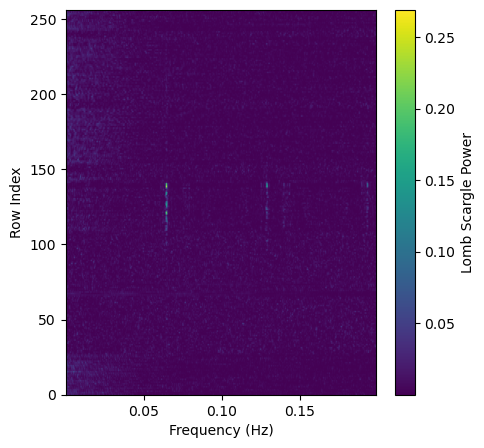

In [67]:
plt.figure(figsize=(5, 5))
plt.imshow(ls_rowwise_pow.T, origin='lower', extent=[ls_rowwise_freq[0], ls_rowwise_freq[-1], 0, 256], aspect='auto')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Row Index')
plt.colorbar(label='Lomb Scargle Power')

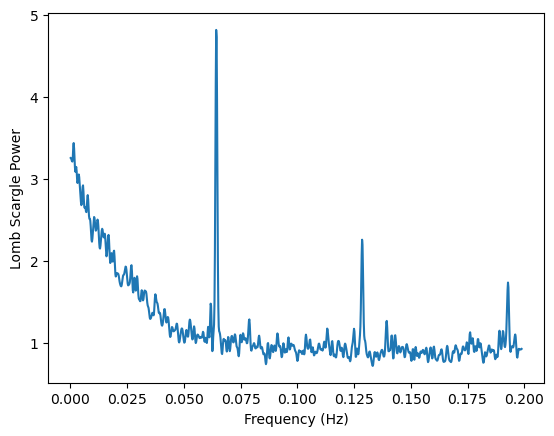

In [68]:
ls_rowwise_summed = np.sum(ls_rowwise_pow, axis=1)
plt.plot(ls_rowwise_freq, ls_rowwise_summed)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Lomb Scargle Power')
plt.show()

In [72]:
peak_f, peak_T = peakfindergeneral(ls_rowwise_freq, ls_rowwise_summed)

TypeError: float() argument must be a string or a real number, not 'numpy.ufunc'

Text(0.5, 0, 'Frequency (Hz)')

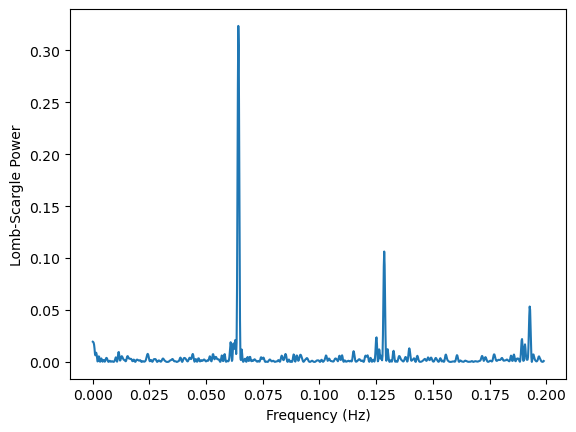

In [18]:
fig, ax = plt.subplots()
ax.plot(frequency, power)
# ax.set_xlim(0.05, 0.075)
plt.ylabel('Lomb-Scargle Power')
plt.xlabel('Frequency (Hz)')

In [19]:
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
    beamwidth = 0.106
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def single_gaussian_fitter(f, p, init_mu, init_sigma, target_name):
    
    # power_range = np.sum(data[:, start_range:end_range], axis=1)
    popt, pcov = curve_fit(gaussian, f, p, p0=[max(p), init_mu, init_sigma])
    A, mu, sigma = popt

    errors = np.sqrt(np.diag(pcov))
    mu_err = errors[1]
    # sigma_err = errors[2]

    x_fit = f
    y_fit = gaussian(f, *popt)
    print('Peak offset = ', mu, 'Hz')
    print('Error = ±', mu_err, 'Hz')
    print('Width = ', sigma, 'Hz')
    print('percentage error', sigma/frequency[np.argmax(power)]*100, '%')
    plt.plot(f, p, label = 'observation')
    plt.plot(x_fit, y_fit, label="Gaussian fit", color ='r')
    plt.xlim(0.05, 0.075)
    plt.xlabel('Frequency')
    plt.ylabel('Power')
    plt.title(target_name)
    plt.legend()
    plt.show()

Peak offset =  0.06426939907499521 Hz
Error = ± 6.496801995959935e-06 Hz
Width =  0.0003527810727432745 Hz
percentage error 0.5493274080751146 %


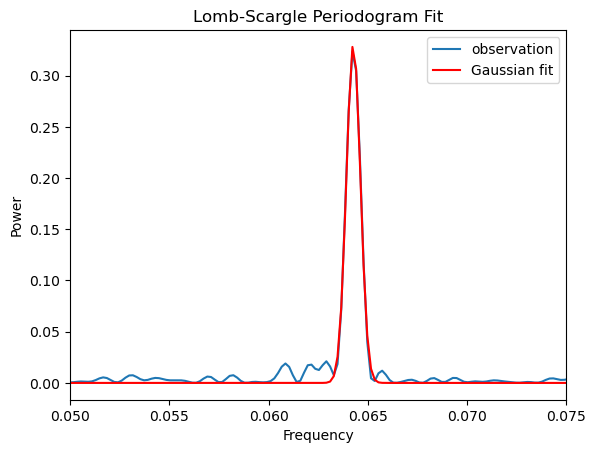

In [20]:
single_gaussian_fitter(frequency, power, frequency[np.argmax(power)], 0.0001, 'Lomb-Scargle Periodogram Fit')

In [21]:
peaks =find_peaks(power, height=np.max(power)*0.1)
peak_freqs = frequency[peaks[0]]
print("Peak frequencies (Hz):", peak_freqs)
print("Corresponding periods (s):", 1/peak_freqs[0])

Peak frequencies (Hz): [0.06422055 0.12853485 0.19266164]
Corresponding periods (s): 15.571340145985403


In [84]:
((0.5493274080751146)/100)*15.57134015

0.08553763924855465

In [22]:
v = vel_tip
print('Corresponding lengths (cm):', ((v*(1/peak_freqs))/(2*np.pi)*100)[0])

Corresponding lengths (cm): 2.855161375833988


In [23]:
((v*((1/peak_freqs[0])+0.09))/(2*np.pi)*100) - ((v*(1/peak_freqs[0]))/(2*np.pi)*100)

np.float64(0.01650240258166269)

TypeError: 'NoneType' object is not callable

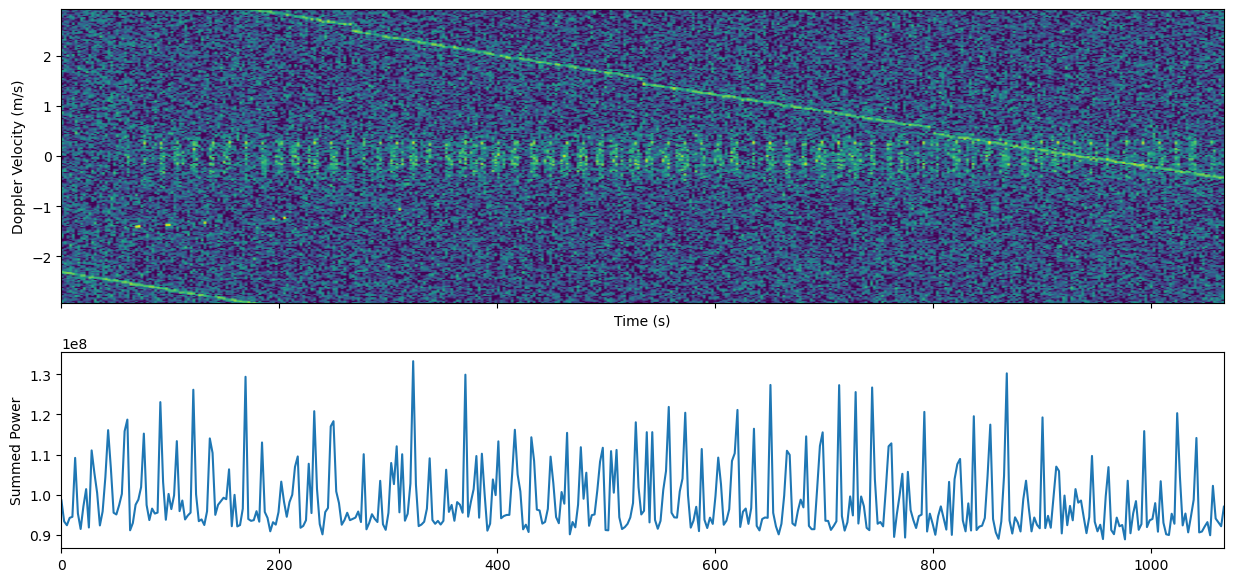

In [24]:
# --- 1. Setup the figure and subplots ---
# sharex=True aligns the x-axes perfectly
# gridspec_kw adjusts the height ratio so the spectrogram is taller
fig, (ax2, ax1) = plt.subplots(
    2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [3, 2]}
)

# --- 2. Top Plot: Line plot (summed_spec) ---
ax1.plot(time, summed_spec)
ax1.set_ylabel("Summed Power")  # Add a label for clarity
# ax1.set_title("Micro-Doppler Spectrogram Analysis") # Optional title


im = ax2.imshow(10 * np.log10(combined_spec+1e-12)-np.max(10 * np.log10(combined_spec+1e-12)), aspect='auto', origin='lower', vmin=-25, vmax=0, extent= [0, time[-1], -max_velocity, max_velocity])

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Doppler Velocity (m/s)")
im.colorbar(label='Power (dB)', ax=ax2)




plt.tight_layout()
plt.show()

In [25]:
print(power.max())

0.3235774758557922


In [26]:
ls = LombScargle(time, summed_spec)

In [27]:
fap = ls.false_alarm_probability(power.max(), method='bootstrap')
fap

np.float64(0.0)

In [28]:
probabilities = [0.1, 0.05, 0.01]
ls.false_alarm_level(probabilities)


array([0.04832958, 0.05174   , 0.05938002])